<a href="https://colab.research.google.com/github/Adriungs/TALENTO_TECH_CIENCIA_DE_DATOS/blob/main/1.CARGA%20DE%20DATOS/2_Analisis_de_datos_credit_risk_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PREGUNTA PRINCIPAL DEL NEGOCIO(Business Problem)

¿Qué características de los solicitantes y de sus préstamos están asociadas con un mayor riesgo de incumplimiento?

<center><font size= "5" ><u>CARGA DE DATOS FORMA 1</u></font></center>

En este caso probamos si tenemos el dataset local con un bucle if... En caso de que no lo encuentre podemos dirigirnos directamente a la página en este caso de kaggle con else donde descargamos el dataset de laotse "laotse/credit-risk-dataset"(nombre del creador/nombre del dataset).

Este método nos permite verificar si tenemos el archivo tanto localmente, pero si por algún motivo se nos perdió el archivo o se cambio de lugar, el código automáticamente lo va a buscar directamente en la página donde se descarga

Esto es para cargas de datos de trabajos donde se use el dataset por un tiempo hasta llegar a una conclusión. Esto es bastante importante tambíen para conectar diferentes fuentes de datos sin tener que andar haciendo trabajo de más moviendo y descargando datasets de forma poco práctica.




In [3]:
import pandas as pd
import os
import numpy as np


ruta_local = "/content/bank.csv"
if os.path.exists(ruta_local):
  ruta_csv = ruta_local
else:
  import kagglehub

  ruta_dataset = kagglehub.dataset_download("laotse/credit-risk-dataset") #Aca se guarda en una carpeta llamada ruta_dataset
  ruta_csv = os.path.join(ruta_dataset, "credit_risk_dataset.csv") #Aca une ó junta la carpeta con el archivo que buscamos de forma segura



Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


In [4]:
bank = pd.read_csv(ruta_csv, sep =",")
print("Dataset cargado correctamente")

Dataset cargado correctamente


In [5]:
display(bank.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


<center><font size= "5" ><u>CARGA DE DATOS FORMA 3</u></font></center>

Esta es la forma más complicada pero la más segura. Aunque se usa solo para proyectos que tienen que durar varios años en porfolios. Si la página donde extraiste el archivo se encuentra caida, podes cargarla desde tu github guardando el dataset entonces cuando una persona ejecute tu código el dataset se va a ejecutar desde tu propia página.

Lo complicado es guardar cada dataset en github


In [6]:
import pandas as pd

#definimos la ruta
url = "https://raw.githubusercontent.com/Adriungs/credit-risk-analysis-pandas/refs/heads/main/data/credit_risk_dataset.csv"

#Leer
tabla = pd.read_csv(url)

tabla.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#CARGA DE DATOS FORMA 4

También podemos usar todas las formas anteriores en un mismo código con if/else pero con try y except.
Es la menos usada de todas pero es muy segura aunque lleva mucho trabajo de carga y es improductivo hacerlo de esta forma


In [7]:
import pandas as pd
import os
import kagglehub

ruta_local = "/content/bank.csv"
url_github = "https://raw.githubusercontent.com/Adriungs/credit-risk-analysis-pandas/refs/heads/main/data/credit_risk_dataset.csv"

# 1. Intenta leer el archivo local primero
if os.path.exists(ruta_local):
    print("Cargando archivo local...")
    tabla = pd.read_csv(ruta_local)

# 2. Si no es local, intenta descargarlo de GitHub (método rápido)
else:
    try:
        print("Intentando cargar desde GitHub...")
        tabla = pd.read_csv(url_github)

    # 3. Si falla GitHub (por falta de internet o URL caída), usa Kagglehub
    except Exception:
        print("GitHub no disponible. Descargando desde Kaggle...")
        ruta_dataset = kagglehub.dataset_download("laotse/credit-risk-dataset")
        ruta_csv = os.path.join(ruta_dataset, "credit_risk_dataset.csv")
        tabla = pd.read_csv(ruta_csv)

# Mostrar las primeras filas para verificar el éxito
print("¡Datos cargados con éxito!")
tabla.head()


Intentando cargar desde GitHub...
¡Datos cargados con éxito!


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


<center><font size= "5" ><u>ANÁLISIS DE DATOS</u></font></center>

Antes de empezar a hacer cualquier tipo de análisis voy a explorar cada columna y anotar sus características:

* person_age = edad de la persona / numérico
* person_income = ingresos personales / numérico
* person_home_ownership = propiedad de la vivienda por parte de la persona /categórico
     * MORTGAGE : hipoteca
     * OWN : propio
     * RENT : renta / alquiler
* person_emp_length = persona duración en su empleo / numérico
* loan_intent = propósito del préstamo / categórico
* loan_grade = calificación del prestamo / categórico
* loan_amnt = monto_del_préstamo / numérico
* loan_int_rate = tasa_de_interés_del_préstamo / numérico
* loan_status = estado_del_préstamo / numérico binario
*	loan_percent_income = porcentaje_de_ingresos_del_préstamo / numérico float porcentual
* cb_person_default_on_file = persona_cb_incumplimiento_en_archivo / categórico
*	cb_person_cred_hist_length = longitud_del_historial_de_créditos_de_la_persona_cb_ / numérico

  

# <font size= "5" ><u>RECONOCIMIENTO DEL DATASET</u></font>

Necesito saber cuantos datos tengo que analizar, estos son bastantes datos

In [8]:
tabla.shape

(32581, 12)

In [9]:
tabla.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [10]:
tabla.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [11]:
tabla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Aca me entere que hay más datos de los que pensaba como nulos y mire nuevamente el .info() para enterarme cuales son las dos columnas que tienen nulos y son estas:
* person_emp_length
* loan_int_rate

In [12]:
tabla.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


Aca puse 2 formas de encontrar las columnas con nulos, la segunda forma como el isnull().sum() cuenta los nulos muchas tienen 0 nulos por eso cuando hacemos suma_nulos > 0 nos da una condición lógica True/False y despues se filtran los que tienen algun nulo mayor a 0.

Aunque ya con .info() ya vimos los nulos y sus columnas

In [13]:
colums_nulos = tabla.columns[tabla.isnull().any()].tolist()
colums_nulos

['person_emp_length', 'loan_int_rate']

In [14]:
suma_nulos = tabla.isnull().sum()
columns_nulos = suma_nulos[suma_nulos > 0]
print(columns_nulos)

person_emp_length     895
loan_int_rate        3116
dtype: int64


En este paso me encontre con varias filas duplicadas sin registro ID de clientes asi que solo puedo eliminarlas ya que no sabemos si es de otro cliente ó si se duplicaron.

In [15]:
tabla.duplicated().sum()

np.int64(165)

In [16]:
tabla[tabla.duplicated()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16


El parámetro keep=False obliga a Pandas a marcar todas las instancias del duplicado (tanto la primera como las repeticiones), y al ordenarlas por una o más columnas, los registros idénticos te quedan agrupados consecutivamente.

pd.set_option('display.max_columns', None) le indica a Pandas que desactive ese límite de columnas y te muestre absolutamente todas las variables del DataFrame, sin importar qué tan ancha sea la tabla.

Al poner None: Le decís que no hay límite máximo de columnas a mostrar.

Resultado: Vas a poder desplazarte de forma horizontal y ver las 12 columnas completas de tu tabla de punta a punta.

In [17]:
pd.set_option('display.max_columns', None)

tabla[tabla.duplicated(keep=False)].sort_values(by=['person_income', 'person_age'])

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15952,24,7800,RENT,1.0,EDUCATION,B,1000,11.36,0,0.13,N,4
16821,24,7800,RENT,1.0,EDUCATION,B,1000,11.36,0,0.13,N,4
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
2471,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
...,...,...,...,...,...,...,...,...,...,...,...,...
16926,22,183000,MORTGAGE,3.0,EDUCATION,A,1000,NaN,0,0.01,N,2
29160,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
27881,28,604000,MORTGAGE,12.0,PERSONAL,B,25000,9.01,1,0.04,N,9


In [18]:
tabla.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# <font size= "5" ><u>LIMPIEZA INICIAL</u></font>

Vamos a empezar detallando los problemas que pudimos ver en el reconocimiento:
1) Hay datos duplicados
2) No hay una columna de id clientes para saber diferenciar
 * Hay datos faltantes en 2 columnas

 3) Hay datos erroneos

Voy a empezar con los duplicados, ya que trabajar con datos duplicados supone un problema muy grande

1)

In [19]:

tabla = tabla.drop_duplicates()

print("Duplicados restantes:", tabla.duplicated().sum())
print("Nuevo tamaño del DataFrame:", tabla.shape)

Duplicados restantes: 0
Nuevo tamaño del DataFrame: (32416, 12)


Aca me fije en .info() para ver que habia pasado con el dataset y resulta que todas las columnas cambiaron su tamaño

In [20]:
tabla.info()


<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  object 
 3   person_emp_length           31529 non-null  float64
 4   loan_intent                 32416 non-null  object 
 5   loan_grade                  32416 non-null  object 
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               29321 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  object 
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


2.

Aca voy agregar un id_cliente para que los valores duplicados se puedan identficar.

Además vemos que .info() dice Index: 32416 entries, 0 to 32580  esto significa que hay 32416 datos pero que hay valores vacios por eso figura 32580 eso lo vamos a arreglar


In [21]:
# 1. Crear el ID
tabla['id_cliente'] = range(1, len(tabla) + 1)

# 2. Reiniciar el índice visual de Pandas para que coincida de 0 a 32415
tabla = tabla.reset_index(drop=True)
tabla.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,id_cliente
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,1
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,4
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,5


El problema ahora es que la columna id_cliente aparece al final entonces la tenemos que eliminar y volver a colocar. Ahora si pude resolver y cada cliente tiene su id único

In [22]:
# 1. Remueve la columna 'id_cliente' y la guarda temporalmente, eso es lo que hace
#  .pop() no las elimina por completo sino que la guarda
col_id = tabla.pop('id_cliente')

# 2. La inserta en la posición 0 (el frente de la tabla), le pone el nombre , llama
# a la variable que guardo .pop
tabla.insert(0, 'id_cliente', col_id)

tabla.head()

,id_cliente,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,1,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,2,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,3,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,4,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,5,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


3.

Aca voy a ver los datos atipicos de cada columna su max y su minimo. Sin embargo en el siguiente codigo me equivoque solo estaba viendo bien la tabla de person_age, lo dejo para que se vea en person_age vemos de mayor a menor pero en las otras columnas esta todo mezclado

In [23]:
tabla[['person_age', 'person_income', 'person_emp_length', 'loan_amnt']].nlargest(10, 'person_age')

,person_age,person_income,person_emp_length,loan_amnt
81,144,250000,4.0,4800
183,144,200000,4.0,6000
32132,144,6000000,12.0,5000
575,123,80004,2.0,20400
747,123,78000,7.0,20000
32251,94,24000,1.0,6500
32341,84,94800,2.0,10000
32257,80,64000,7.0,6800
32190,78,48000,41.0,3000
32369,76,75000,23.0,15000


Puedo hacer todas asi para cada columna:

In [24]:
tabla['person_emp_length'].nlargest(10)

,person_emp_length
0,123.0
210,123.0
32190,41.0
32350,38.0
32263,34.0
30755,31.0
31707,31.0
31708,31.0
32099,31.0
32374,30.0


Pero existe otra forma automatizada


Si le sacás el .values, Pandas intentará alinear las columnas usando el índice original de cada cliente. Como los 10 clientes con mayor edad no son las mismas personas que los 10 clientes con mayor ingreso, los índices no van a coincidir y la tabla se llenaría de valores NaN.





In [25]:

columnas = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt']

# Crea un DataFrame donde cada columna tiene sus 10 valores máximos ordenados independientemente
max10 = pd.DataFrame({col: tabla[col].nlargest(10).values for col in columnas})
max10

,person_age,person_income,person_emp_length,loan_amnt
0,144,6000000,123.0,35000
1,144,2039784,123.0,35000
2,144,1900000,41.0,35000
3,123,1782000,38.0,35000
4,123,1440000,34.0,35000
5,94,1362000,31.0,35000
6,84,1200000,31.0,35000
7,80,1200000,31.0,35000
8,78,1200000,31.0,35000
9,76,948000,30.0,35000


In [26]:
min10 = pd.DataFrame({col: tabla[col].nsmallest(10).values for col in columnas})
min10

,person_age,person_income,person_emp_length,loan_amnt
0,20,4000,0.0,500
1,20,4080,0.0,500
2,20,4200,0.0,500
3,20,4200,0.0,500
4,20,4800,0.0,500
5,20,4800,0.0,700
6,20,4800,0.0,725
7,20,4888,0.0,750
8,20,5000,0.0,800
9,20,5000,0.0,900


Aca buscamos el maximo de person_age

In [27]:
tabla.loc[[tabla['person_age'].idxmax()]]

,id_cliente,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,82,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3


Aca filtre todas las columnas filtradas a mayores a 100

In [28]:
tabla[tabla['person_age'] > 100]

,id_cliente,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,82,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,184,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,576,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,748,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32132,32133,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


Esta parte es bastante importante:

El .where() en esa instrucción funciona al revés de lo que suele sugerir el nombre en lenguaje cotidiano:

En Pandas, la sintaxis donde_es_true.where(condicion) mantiene los valores que CUMPLEN la condición y convierte en vacíos (NaN) a los que NO la cumplen.

Quite las edades mayores a 100, y agrupe todas las antiguedades...Con eso donde donde se quitaron las edades rellene con la media de edad segun su antiguedad.
En este caso tenia que resolver las edades mayores a 100

In [29]:
# Mantiene solo las edades <= 100
tabla['person_age'] = tabla['person_age'].where(tabla['person_age'] <= 100)

# Rellena e imputa
media_edad = tabla.groupby('person_emp_length')['person_age'].transform('mean')
tabla['person_age'] = tabla['person_age'].fillna(media_edad).round().astype(int)

# Filtra exactamente a los clientes que tenían edades > 100
tabla[tabla['id_cliente'].isin([82, 184, 576, 748, 32133])][['id_cliente', 'person_emp_length', 'person_age']]

,id_cliente,person_emp_length,person_age
81,82,4.0,28
183,184,4.0,28
575,576,2.0,28
747,748,7.0,26
32132,32133,12.0,30


Trabajando con los datos me di cuenta que las edades tenian años de antiguedades que no eran lo común. Asi que se removieron 737 registros donde la edad de inicio laboral calculada era menor a 16 años. Decidi borrarlos porque no puedo inventar años de antiguedad, si bien talvez habian mas datos que nos podrian servir más adelante podria ser un problema. Además solo es un 2% de datos borrados del total del dataset

In [30]:
# Filtra las filas donde (Edad - Antigüedad) sea menor a 16 años
empleabilidad = tabla[tabla['person_age'] - tabla['person_emp_length'] < 16]

# Muestra los datos relevantes de esas personas
empleabilidad[['id_cliente', 'person_age', 'person_emp_length', 'person_income']]

,id_cliente,person_age,person_emp_length,person_income
0,1,22,123.0,59000
9,10,21,6.0,10000
18,19,23,8.0,113000
65,66,22,7.0,12000
68,69,24,9.0,255000
...,...,...,...,...
31708,31709,46,31.0,180000
32043,32044,40,25.0,66000
32099,32100,46,31.0,180000
32121,32122,36,21.0,48686


In [31]:
tabla[['person_emp_length', 'person_age']].nlargest(10, 'person_emp_length')

,person_emp_length,person_age
0,123.0,22
210,123.0,21
32190,41.0,78
32350,38.0,53
32263,34.0,58
30755,31.0,48
31707,31.0,47
31708,31.0,46
32099,31.0,46
32374,30.0,61


In [32]:
# Mantiene solo las filas donde la persona empezó a trabajar a los 16 años o más
tabla = tabla[tabla['person_age'] - tabla['person_emp_length'] >= 16].copy()

# Reinicia el índice
tabla = tabla.reset_index(drop=True)

In [33]:
# Consultar los 5 valores máximos de antigüedad
tabla.shape

(30792, 13)

In [34]:
tabla.head()

,id_cliente,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,2,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,3,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,4,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,5,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,6,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


3.

Ahora vamos a tratar los datos faltantes y ver de que forma los podemos resolver

In [35]:
# 1. Calcular la cantidad de nulos por columna
nulos = tabla.isnull().sum()
# Muestra solo las columnas que tienen al menos 1 valor nulo

nulos[nulos > 0]
print(nulos)
print("------" *10)
# 2. Calcular el porcentaje sobre el total de filas
nulos_porcentaje = (nulos / len(tabla)) * 100
print(nulos_porcentaje)



id_cliente                       0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2951
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
------------------------------------------------------------
id_cliente                    0.000000
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.583658
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_

Aca pude usar missignio y aunque no me averiguo nada este grafico me ayudo a comprender que si hubiera faltantes en otra columna me ayuda a visualizar si esos nulos estan relacionados...En este caso no hay pero me sirve dejarlo para saber en un próximo análisis de datos

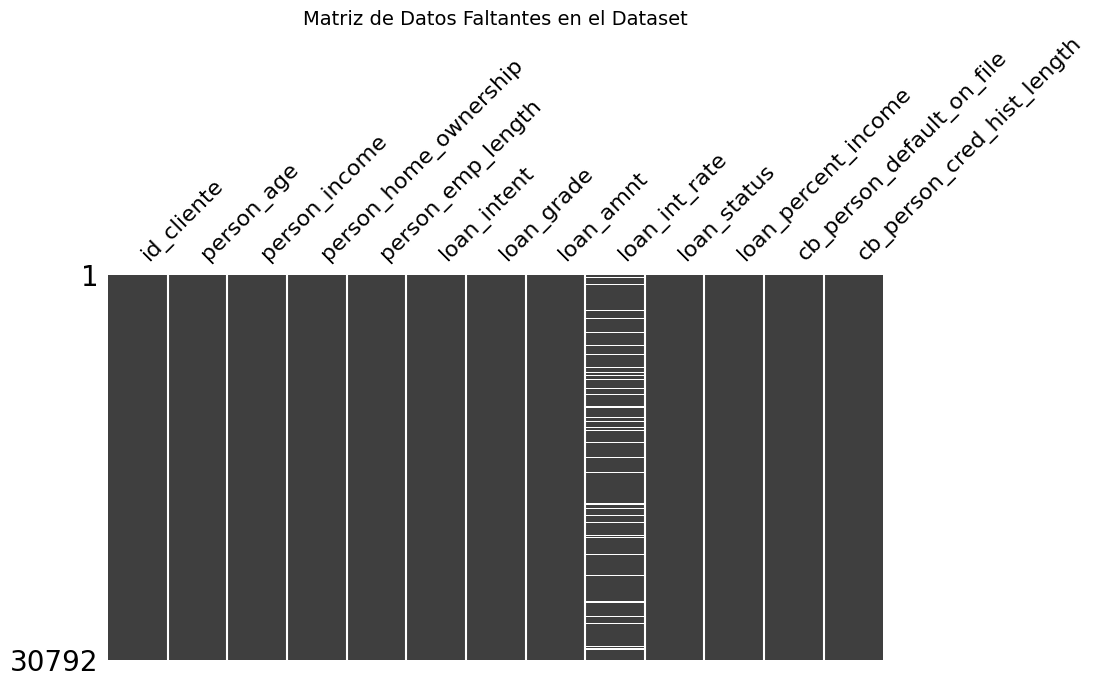

In [36]:
import missingno as msno
import matplotlib.pyplot as plt

# Matriz visual de nulos
msno.matrix(tabla, figsize=(10, 5), sparkline=False)
plt.title('Matriz de Datos Faltantes en el Dataset', fontsize=14)
plt.show()

En esta instancia lo que voy a ver es el loan_grade y cuantos prestamos totales se dieron y también vemos un aumento en la tasa de interes a medida que crece es riesgo o la categoria de riesgo

In [37]:
# Ver la mediana y el promedio de tasa por cada grado
tabla.groupby('loan_grade')['loan_int_rate'].agg(['count', 'median', 'mean', 'std']).round(2)

,count,median,mean,std
loan_grade,,,,
A,9107,7.49,7.35,1.04
B,8889,10.99,11.01,0.91
C,5563,13.48,13.45,0.96
D,3172,15.31,15.35,1.11
E,850,16.77,17.00,1.33
F,205,18.53,18.59,1.39
G,55,20.16,20.26,1.07


Queria ver si tenian correlación la tasa de interes con el loan_grade, es una de las cosas principales que buscar. Osea puedo ver si tienen relación o no. Gracias a este gráfico puedo decir que si pero voy a seguir para ver si esto es efectivamente correcto

/tmp/ipykernel_2699/3290983905.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tabla, x='loan_grade', y='loan_int_rate', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'], palette='viridis')


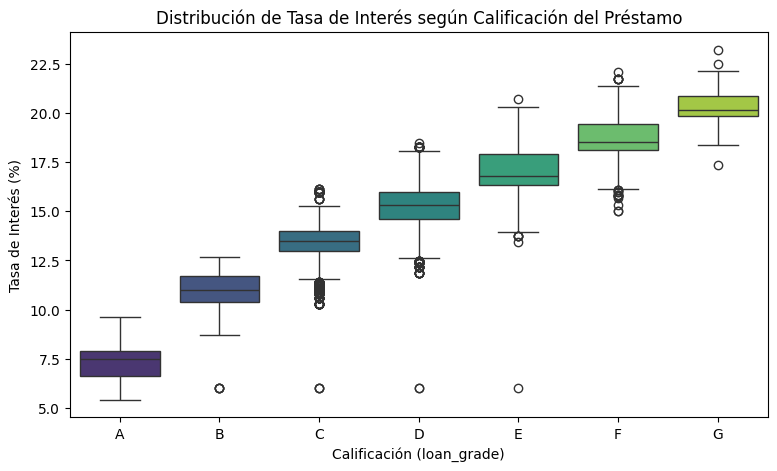

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
sns.boxplot(data=tabla, x='loan_grade', y='loan_int_rate', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'], palette='viridis')
plt.title('Distribución de Tasa de Interés según Calificación del Préstamo')
plt.xlabel('Calificación (loan_grade)')
plt.ylabel('Tasa de Interés (%)')
plt.show()

In [39]:
from scipy.stats import kruskal

# Preparamos los datos eliminando los NaN temporales para la prueba
grupos = [grupo['loan_int_rate'].dropna() for _, grupo in tabla.groupby('loan_grade')]

# Ejecutamos Kruskal-Wallis
stat, p_value = kruskal(*grupos)
print(f"Estadístico H: {stat:.2f}")
print(f"p-value: {p_value:.4e}")

Estadístico H: 24996.40
p-value: 0.0000e+00


Hice un countplot pero todavia no pude encontrar nada me dio más dudas...Mis dudas aca fueron si los datos faltantes eran pocos o muchos, y para saber eso tenia que ver las categorías para poder saber que hacer con los nulos no basta con un simple gráfico sino que lleva a una serie de preguntas

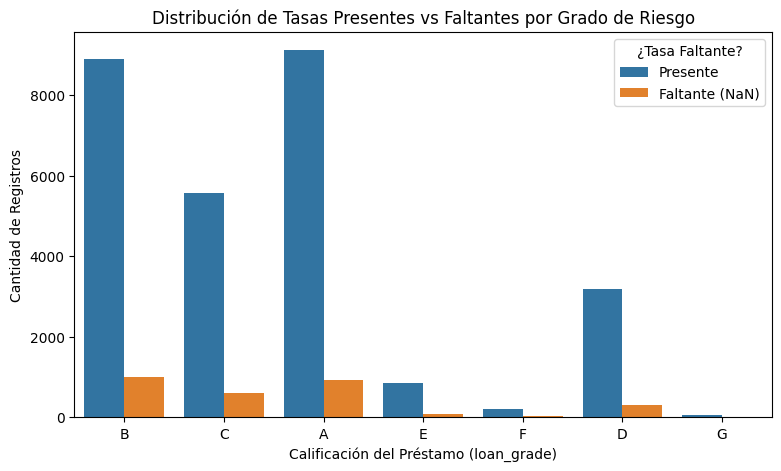

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una variable temporal para identificar el nulo
tabla['tasa_es_null'] = tabla['loan_int_rate'].isnull()

plt.figure(figsize=(9, 5))
sns.countplot(data=tabla, x='loan_grade', hue='tasa_es_null')
plt.title('Distribución de Tasas Presentes vs Faltantes por Grado de Riesgo', fontsize=12)
plt.xlabel('Calificación del Préstamo (loan_grade)')
plt.ylabel('Cantidad de Registros')
plt.legend(title='¿Tasa Faltante?', labels=['Presente', 'Faltante (NaN)'])

# Limpiar la columna temporal
tabla.drop(columns=['tasa_es_null'], inplace=True)
plt.show()

Lo primero a resolver fue cuanto me representaban los nulos en cada grado de riesgo crediticio.

loan_grade (Calificación del préstamo - A, B, C, D, E, F, G): Es la variable determinante. Refleja la categoría de riesgo que la entidad le asignó al cliente


La cuestion aca es que todavia no sabia que tanto representaban esos nulos en cada

In [41]:
(tabla['loan_int_rate'].isna() #True NaN vale 1 y False con valor vale 0
 .groupby(tabla['loan_grade']) #Agrupa 0 y 1 según loan_grade (A, B, C, D, E, F, G)
 .mean()                       #Calcula el promedio = cantidad de True(1) / cantidad total de registros
 .mul(100)                     #Multiplica por 100 Convierte la proporción decimal a escala porcentual (ejemplo: 0.0927 pasa a 9.27
 .round(2)                     #Redondea a 2 decimales
 .astype(str) + '%'            #Convierte los números redondeados en tipo texto (string) y le concatena el símbolo '%' al final para generar el formato legible (ejemplo: '9.27%'
)

,loan_int_rate
loan_grade,
A,9.27%
B,10.12%
C,9.88%
D,8.64%
E,8.5%
F,11.26%
G,8.33%


Aca lo que hice fue aplicar en pandas el pd.crosstab y normalizarlo, ponerle una linea en 91 en el eje y

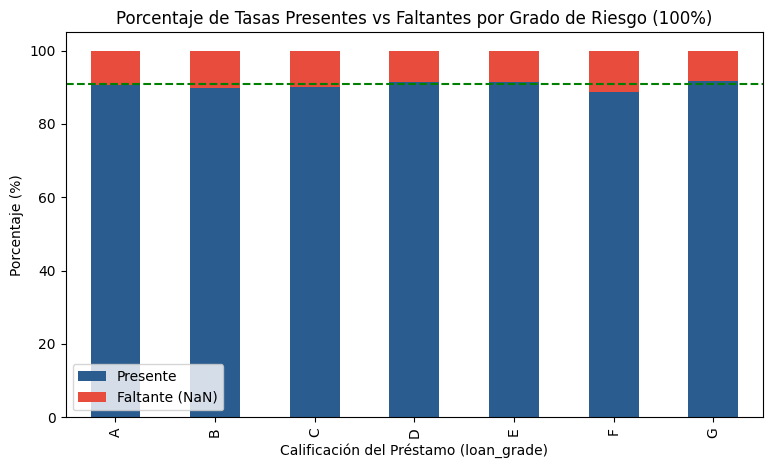

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear tabla de frecuencias relativas (porcentajes)
tabla_porcentajes = pd.crosstab(      #toma dos (o más) columnas de un DataFrame o listas de datos y cuenta cuántas veces coinciden los valores entre ellas
    tabla['loan_grade'],
    tabla['loan_int_rate'].isnull(),
    normalize='index'                 #"normalizar al mismo nivel" significa cambiar la escala de cada grupo para que la suma de sus partes siempre valga 1.0
) * 100

# Graficar
tabla_porcentajes.plot(kind='bar', stacked=True, color=['#2b5c8f', '#e74c3c'], figsize=(9, 5))
plt.title('Porcentaje de Tasas Presentes vs Faltantes por Grado de Riesgo (100%)')
plt.xlabel('Calificación del Préstamo (loan_grade)')
plt.ylabel('Porcentaje (%)')
plt.legend(['Presente', 'Faltante (NaN)'])
plt.axhline(y=91, color='green', linestyle='--') # Línea de referencia en este caso lo dejamos en 91
plt.show()

¿Cómo saber si la variación es relevante según el p-value?Si el p-value es > 0.05: Se concluye que no hay diferencia significativa entre las calificaciones. La variación es atribuible al azar y podés imputar con total confianza.Si el p-value es < 0.05: La diferencia es estadísticamente significativa, lo que te avisa que la falta de dato sí guarda alguna relación estructural con la categoría.

Se evaluó la distribución de los 2,951 valores faltantes (9.07%) de la variable loan_int_rate respecto a las categorías de riesgo (loan_grade). La proporción de nulos osciló entre el 8.33% y el 11.26% por grupo. Para verificar la independencia, se aplicó una prueba de Chi-Cuadrado de independencia, obteniendo un $p$-value de 0.0957 ($p > 0.05$). Al no existir evidencia estadística de sesgo entre las calificaciones, los datos faltantes se consideran faltantes completamente al azar (MCAR) dentro de la estructura de riesgo, validando la imputación mediante la mediana agrupada por loan_grade."


* Es un olvido aleatorio del sistema, no un truco: La prueba demostró que los datos faltan por igual en clientes de bajo riesgo (A) y de alto riesgo (G). Ningún grupo "oculta" sus tasas.

* Como las tasas dependen del riesgo, al rellenar los huecos usando la mediana de cada categoría (loan_grade), le asignás a cada cliente la tasa justa que le corresponde a su perfil sin distorsionar el análisis.

Básicamente al estar todas en iguales condiciones no es algo especial de un solo grado y al estar las tasas riesgos asociados a sus Grados o Categórias entonces se pueden imputar debido a esa vinculación

In [43]:
from scipy.stats import chi2_contingency

# Creamos una tabla de contingencia (conteo real de presentes vs nulos por grupo)
tabla_contingencia = pd.crosstab(tabla['loan_grade'], tabla['loan_int_rate'].isnull())

# Ejecutamos la prueba de Chi-Cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

print(f"p-value: {p_value:.4f}")

p-value: 0.0957


Una desviación estándar de ~1.05% te indica que, en promedio, las categorías se alejan solo un $1\%$ del promedio general. Eso confirma formalmente que la dispersión es mínima.

En este caso me entro la duda de si es mucha la desviación es mucha o poca

In [44]:
import pandas as pd

# Guardamos los porcentajes de nulos
porcentajes = pd.Series([9.27, 10.12, 9.88, 8.64, 8.50, 11.26, 8.33])

print("Promedio de nulos:", porcentajes.mean())
print("Desviación estándar:", porcentajes.std())
print("Rango (Diferencia Max - Min):", (porcentajes.max() - porcentajes.min()))

Promedio de nulos: 9.428571428571429
Desviación estándar: 1.060824028313659
Rango (Diferencia Max - Min): 2.9299999999999997


Ahora si despues de todo este análisis puedo imputar con mediana los NAN en el dataset recordemos que los NaN representaban aproximadamente un 9% del dataset...Y que se encontraban en datos sensibles, además que anteriormente ya se habian borrado algunos datos que representaban una minoria pero no eran datos sensibles

In [45]:
tabla['loan_int_rate'] = tabla['loan_int_rate'].fillna(
    tabla.groupby('loan_grade')['loan_int_rate'].transform('median')
)

In [46]:
tabla['loan_int_rate'].isnull().sum()

np.int64(0)

Antes de avanzar algo que quiero dejar en claro del loan_grade:
El loan_grade es el resumen del riesgo total
El banco no asigna la letra A, B, C... de forma aleatoria. La calificación es el resultado de un algoritmo interno (Score de Crédito) que ya evaluó conjuntamente:

El salario del cliente (person_income).

Su situación habitacional (person_home_ownership).

Su antigüedad laboral (person_emp_length).

El monto del préstamo (loan_amnt) y su relación con el ingreso (loan_percent_income).

Es decir, si dos personas tienen ingresos y antecedentes distintos pero ambas terminaron clasificadas como loan_grade = A, es porque el banco determinó que sus perfiles consolidados representan el mismo nivel de riesgo. Por lo tanto, a ambas les corresponde el mismo rango de tasa.

#EDA

##COMPOSICIÓN GENERAL DEL DATASET



Antes de empezar a hacer cualquier tipo de análisis voy a explorar cada columna y anotar sus características:

###NUMÉRICAS

* person_age = edad de la persona / numérico
   * ¿La edad presenta diferencias según el estado del préstamo?
* person_income = ingresos personales / numérico
   * ¿El nivel de ingresos presenta diferencias entre los grupos? repercute en el default?
* person_emp_length = persona duración en su empleo / numérico
   *
* loan_amnt = monto_del_préstamo / numérico
   * ¿Los montos son diferentes según loan_status?
* loan_int_rate = tasa_de_interés_del_préstamo / numérico
   * ¿La tasa presenta diferencias entre los grupos?Que una tasa sea mas alta o baja repercute en loan_status?
*	loan_percent_income = porcentaje_de_ingresos_del_préstamo/ Proporción del ingreso personal destinada al préstamo. / numérico float porcentual
*	cb_person_cred_hist_length = longitud_del_historial_de_créditos_de_la_persona_cb_ / numérico

---

###CATEGÓRICOS
* person_home_ownership = propiedad de la vivienda por parte de la persona /categórico
     * MORTGAGE : hipoteca
     * OWN : propio
     * RENT : renta / alquiler
        * ¿La tasa de default varía según la vivienda?
* loan_intent = propósito del préstamo / categórico
* loan_grade = calificación del prestamo / categórico
   * ¿Las categorías tienen diferentes tasas de default?

---

###BINARIO
* loan_status = estado_del_préstamo / numérico binario
* cb_person_default_on_file = persona_cb_incumplimiento_en_archivo / categórico
   * ¿El historial previo se relaciona con el estado actual?

In [47]:
tabla.describe().T

,count,mean,std,min,25%,50%,75%,max
id_cliente,30792.0,16324.079566,9355.265520,2.00,8230.75,16379.50,24435.25,32416.00
person_age,30792.0,27.811704,6.249950,20.00,23.00,26.00,30.00,94.00
person_income,30792.0,66674.585607,62907.254125,4000.00,39000.00,55800.00,80000.00,6000000.00
person_emp_length,30792.0,4.662153,3.967310,0.00,2.00,4.00,7.00,41.00
loan_amnt,30792.0,9646.744284,6339.000866,500.00,5000.00,8000.00,12375.00,35000.00
loan_int_rate,30792.0,11.052679,3.200503,5.42,7.90,10.99,13.48,23.22
loan_status,30792.0,0.216225,0.411676,0.00,0.00,0.00,0.00,1.00
loan_percent_income,30792.0,0.169487,0.106310,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,30792.0,5.854280,4.085488,2.00,3.00,4.00,8.00,30.00


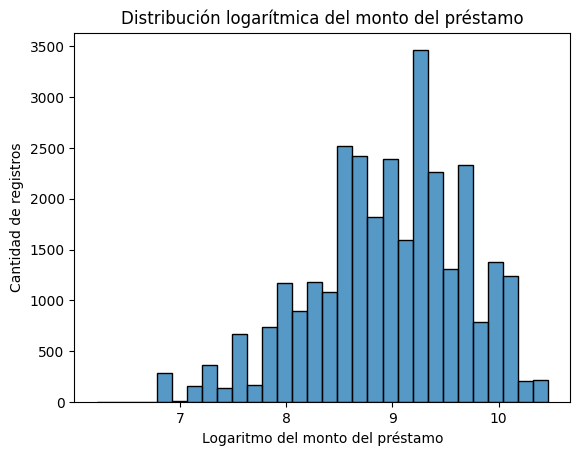

In [48]:
tabla["loan_amnt_log"] = np.log1p(tabla["loan_amnt"])

sns.histplot(data=tabla, x="loan_amnt_log", bins=30)

plt.title("Distribución logarítmica del monto del préstamo")
plt.xlabel("Logaritmo del monto del préstamo")
plt.ylabel("Cantidad de registros")
plt.show()

In [49]:
tabla["loan_amnt_log"].describe()

,loan_amnt_log
count,30792.000000
mean,8.949344
std,0.708271
min,6.216606
25%,8.517393
50%,8.987322
75%,9.423514
max,10.463132


###DISTRIBUCIÓN DE LOAN_STATUS

Aca intente ver como estaba distribuido loan_status

¿Cómo se distribuyen los préstamos entre default (1) y no default (0)?

In [50]:
tabla["loan_status"].value_counts()

,count
loan_status,
0,24134
1,6658


Con normalize=True (Proporción / Porcentaje)

En lugar de decirte cuántas personas eligieron cada opción, te dice qué parte del total representa cada grupo.

Divide el conteo de cada grupo entre el total (8 / 10 y 2 / 10):

Pizza: 0.8 (es decir, el 80%)

Empanadas: 0.2 (es decir, el 20%)

In [51]:
tabla["loan_status"].value_counts(normalize=True) * 100

,proportion
loan_status,
0,78.377501
1,21.622499


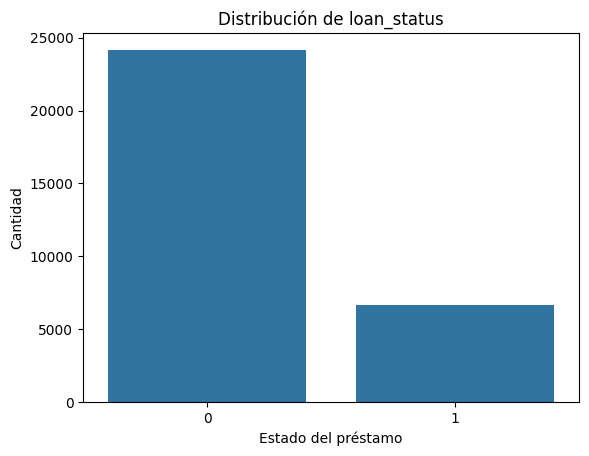

In [52]:
sns.countplot(data=tabla, x="loan_status")

plt.title("Distribución de loan_status")
plt.xlabel("Estado del préstamo")
plt.ylabel("Cantidad")
plt.show()

##ANÁLISIS GENERAL DEL RIESGO

###ANÁLISIS SOBRE LAS CATEGÓRICAS

Para cada categoría podemos calcular la tasa de default:

Las variables categóricas (como loan_grade, loan_intent o person_home_ownership) dividen a la población en "cajas" o grupos.

¿Por qué se saca la tasa de default?

Porque dentro de cada una(al ser categorica) querés saber qué porcentaje de personas falló. La tasa de default es simplemente la proporción de 1s dentro de esa categoría.

Te responde a la pregunta: «¿En qué grupo es más riesgoso prestar?»

Ejemplo en person_home_ownership: Calculás la tasa de default para los que alquilan (RENT), los que tienen hipoteca (MORTGAGE) y los que son dueños (OWN). Si los que alquilan tienen 30% de default y los dueños 7%, ya sabés que la vivienda es una variable filtro muy importante.

¿Qué significa loan_status = 0 y 1?
En la documentación formal de este dataset de riesgo crediticio (Credit Risk Dataset):

0 = Non-default / Pagó: Significa que el cliente cumplió con sus obligaciones y devolvió el préstamo en tiempo y forma.

1 = Default / Incumplió: NO significa que el préstamo fue rechazado o aceptado por el banco. Significa que el préstamo fue otorgado y el cliente cayó en mora/default (no lo pagó).

In [53]:
tabla.groupby("loan_grade")["loan_status"].mean().mul(100)

,loan_status
loan_grade,
A,9.534722
B,15.935288
C,20.200875
D,59.158986
E,64.908504
F,70.129870
G,98.333333


Las categorías A, B y C concentran a la gran mayoría de los clientes y tienen tasas de default bajas, mientras que de D a G la tasa de default se dispara y hay muchísima menos gente.

La entidad financiera opera con una política de riesgo conservadora: aprueba a la mayoría de las personas en perfiles de bajo/medio riesgo. A las categorías D a G casi no les aprueba créditos (son muy pocos clientes) porque la probabilidad de que no paguen es altísima (supera el 50%).

In [54]:
# Conteo absoluto y porcentaje del total de clientes
distribucion = pd.DataFrame({
    'Cantidad_Clientes': tabla['loan_grade'].value_counts(),
    'Porcentaje_del_Total': tabla['loan_grade'].value_counts(normalize=True) * 100
}).sort_index()

distribucion

,Cantidad_Clientes,Porcentaje_del_Total
loan_grade,,
A,10037,32.596129
B,9890,32.118732
C,6173,20.047415
D,3472,11.275656
E,929,3.017017
F,231,0.750195
G,60,0.194856


In [55]:
tabla.groupby("person_home_ownership")["loan_status"].mean().mul(100)

,loan_status
person_home_ownership,
MORTGAGE,12.530635
OTHER,31.428571
OWN,6.976744
RENT,31.038432


DEBTCONSOLIDATION (Consolidación de deuda): Significa que el cliente está pidiendo un préstamo nuevo para pagar otras deudas que ya tiene. Esto refleja que la persona está sobreendeudada o con problemas de liquidez previa. Por eso la tasa de default es más alta (28.3%).

VENTURE (Inversión/Emprendimiento) y EDUCATION (Educación): Tienen menor tasa de default (14.8% y 17%) porque suelen ser inversiones que generan retorno o desarrollo personal, asociadas a perfiles con mejor planificación.

In [56]:
tabla.groupby("loan_intent")["loan_status"].mean().mul(100)

,loan_status
loan_intent,
DEBTCONSOLIDATION,28.298823
EDUCATION,16.988290
HOMEIMPROVEMENT,25.727590
MEDICAL,26.614447
PERSONAL,19.473081
VENTURE,14.877415


cb_person_default_on_file indica si el cliente registra antecedentes previos de incumplimiento/default en el veraz o buró de crédito.

Y (Yes): El cliente ya figura en el historial con un default o mora previa registrada.

N (No): El cliente tiene un historial limpio (o sin registros de incumplimiento previo).

N → ~18.14%: De los clientes que no tenían antecedentes negativos, solo el 18.14% cayó en default con este nuevo préstamo.

Y → ~37.65%: De los clientes que sí tenían antecedentes negativos en el buró, el 37.65% volvió a defaultear (más del doble de riesgo).

Tener antecedentes negativos en el historial incrementa drásticamente la probabilidad de que la persona vuelva a incumplir.

Esto nos permite detectar rápidamente, por ejemplo:

¿Hay categorías donde la proporción de incumplimiento sea claramente mayor?

No estoy concluyendo todavía que una variable sea importante; estoy buscando señales para decidir qué analizar después.

In [57]:
tabla.groupby("cb_person_default_on_file")["loan_status"].mean().mul(100)

,loan_status
cb_person_default_on_file,
N,18.138689
Y,37.650055


###ANÁLISIS SOBRE NUMÉRICAS

Acá puedo hacer una primera comparación entre loan_status = 0 y loan_status = 1:

Miro los resultados y seleccionamos las que muestro diferencias o patrones interesantes para hacer el análisis individual.

Ese es justamente el propósito del análisis general del riesgo: funcionar como un filtro para decidir dónde profundizar.

In [58]:
tabla.groupby("loan_status")[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "cb_person_cred_hist_length"
    ]
].median()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
loan_status,,,,,,,
0,26.0,60000.0,4.0,8000.0,10.65,0.13,4.0
1,26.0,42000.0,3.0,10000.0,13.48,0.24,4.0


In [59]:
tabla.groupby("loan_status")[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "cb_person_cred_hist_length"
    ]
].describe()

person_age                                                     \
                 count       mean       std   min   25%   50%   75%   max   
loan_status                                                                 
0              24134.0  27.886964  6.234807  20.0  23.0  26.0  30.0  94.0   
1               6658.0  27.538901  6.297473  20.0  23.0  26.0  30.0  70.0   

            person_income                                               \
                    count          mean           std     min      25%   
loan_status                                                              
0                 24134.0  71304.095716  67663.885632  7000.0  42200.0   
1                  6658.0  49893.480625  36701.912845  4000.0  30000.0   

                                         person_emp_length            \
                 50%      75%        max             count      mean   
loan_status                                                            
0            60000.0  85000.0  6000000.0           24134.0  4.844037   
1            42000.0  60000.0   703800.0            6658.0  4.002854   

                                                loan_amnt                \
                  std  min  25%  50%  75%   max     count          mean   
loan_status                                                               
0            3.993120  0.0  2.0  4.0  7.0  41.0   24134.0   9273.312547   
1            3.800314  0.0  1.0  3.0  6.0  34.0    6658.0  11000.364223   

                                                                    \
                     std    min     25%      50%      75%      max   
loan_status                                                          
0            6043.009889  500.0  5000.0   8000.0  12000.0  35000.0   
1            7151.020552  900.0  5000.0  10000.0  15000.0  35000.0   

            loan_int_rate                                                  \
                    count       mean       std   min    25%    50%    75%   
loan_status                                                                 
0                 24134.0  10.481425  2.943969  5.42   7.66  10.65  12.69   
1                  6658.0  13.123370  3.238452  5.42  10.99  13.48  15.37   

                   loan_percent_income                                        \
               max               count      mean       std   min   25%   50%   
loan_status                                                                    
0            22.06             24134.0  0.148286  0.086778  0.00  0.08  0.13   
1            23.22              6658.0  0.246335  0.132058  0.01  0.14  0.24   

                        cb_person_cred_hist_length                           \
              75%   max                      count      mean       std  min   
loan_status                                                                   
0            0.20  0.83                    24134.0  5.891439  4.074156  2.0   
1            0.34  0.78                     6658.0  5.719585  4.123806  2.0   

                                  
             25%  50%  75%   max  
loan_status                       
0            3.0  4.0  8.0  30.0  
1            3.0  4.0  8.0  30.0

##SELECCIÓN DE VARIABLES Y RELACIONES

Estas son algunas de las variables que me parecieron interesantes

LOAN GRADE

calificación del prestamo / categórico

Lo que encontré fue que la relacion de loan status varia de forma degradada segun sus grados, esto puede tener una buena explicación en el análisis de datos, puede explicar algo del loan_status.




PERSON_HOME_OWNERSHIP

propiedad de la vivienda por parte de la persona /categórico

Aca aparece que los que tienen hipoteca y tienen casa propia tienen menos riesgo de default...Esto también nos ayuda en el análisis de datos

LOAN_INTENT

propósito del préstamo / categórico

Aca también pude visualizar que los que por ejemplo los estudiantes tenian mas capacidad de pago, que alguien que ya debia...Representaban menos riesgos los estudiantes que los que ya tenian algun prestamo


CB_PERSON_DEFAULT_ONFILE

Indica si el cliente registra antecedentes previos de incumplimiento/default en el veraz o buró de crédito... Y/N

Aca pude ver que la diferencia entre quienes no cumplen y si cumplen...Si ya estuvieron en el veraz seguro tengan mas incapacidad de pago nuevamente



LOAN_PERCENT_INCOME

Porcentaje_de_ingresos_del_préstamo/ Proporción del ingreso personal destinada al préstamo. / numérico float porcentual

PERSON_AGE

Quiero ver si la edad influye o no en el pago también, aunque nada lo indica prefiero descartarla

##ANÁLISIS BIVARIADO E INDIVIDUAL DE VARIABLES RELEVANTES

PERSON_AGE

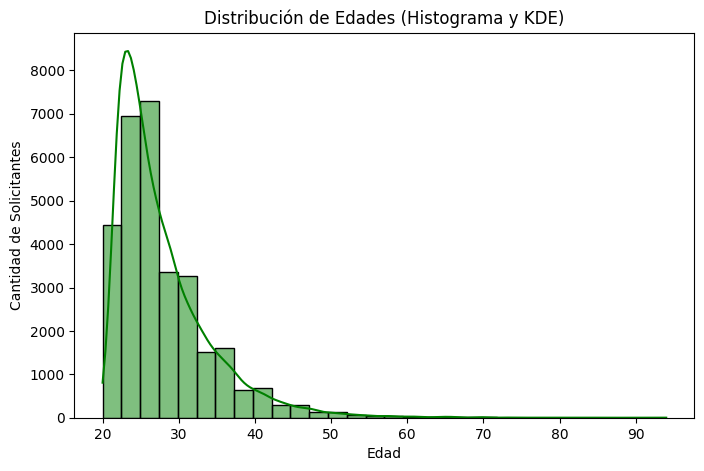

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Histograma + KDE
sns.histplot(data=tabla, x='person_age', bins=30, kde=True, color='green')

plt.title('Distribución de Edades (Histograma y KDE)')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Solicitantes')

plt.show()

###PERSON_AGE Y LOAN_STATUS

/tmp/ipykernel_2699/1064330675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


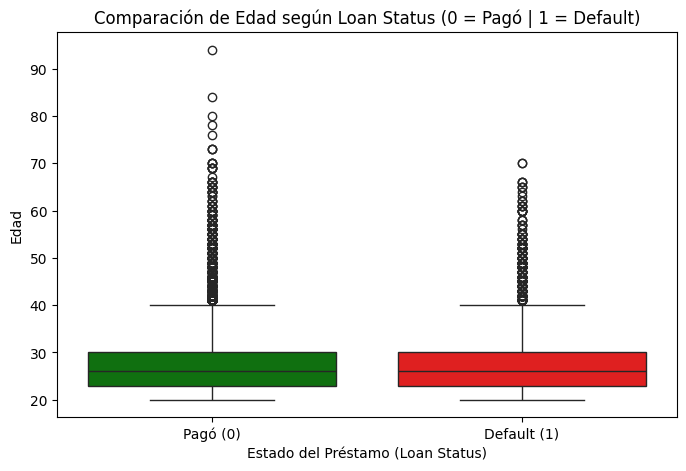

In [61]:

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=tabla,
    x='loan_status',
    y='person_age',
    palette=['green', 'red']
)

plt.title('Comparación de Edad según Loan Status (0 = Pagó | 1 = Default)')
plt.xlabel('Estado del Préstamo (Loan Status)')
plt.ylabel('Edad')
plt.xticks([0, 1], ['Pagó (0)', 'Default (1)'])
plt.show()

pd.cut = Toma una columna con números (en tu caso tabla['person_age']) y reemplaza cada número por el rango al que pertenece. Transforma una variable numérica en una categórica.


Bins = Define los puntos de corte (límites) para armar los rangos.

Si tenés bins=[18, 25, 30, 40, 60, 100], Pandas armará los siguientes intervalos:

De 18 a 25 años: (18, 25]

De 25 a 30 años: (25, 30]...

La edad aca podemos ver que no hay relación que de datos relevantes con loan_status

In [62]:
# Crear rangos de edad
tabla['rango_edad'] = pd.cut(tabla['person_age'], bins=[18, 25, 30, 40, 60, 100], labels=['18-25', '26-30', '31-40', '41-60', '60+'])

# Tasa de default por rango de edad
tabla.groupby('rango_edad', observed = False)['loan_status'].mean().mul(100)

,loan_status
rango_edad,
18-25,22.910693
26-30,20.751362
31-40,20.026459
41-60,20.722022
60+,26.562500


LOAN_GRADE

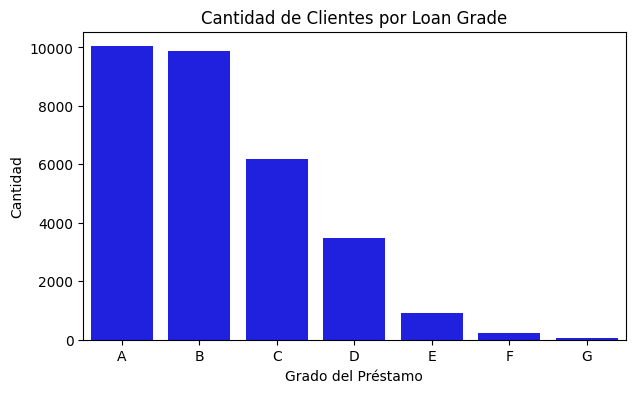

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))

# Gráfico de barras simple
sns.countplot(
    data=tabla,
    x='loan_grade',
    order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    color='Blue'
    )

plt.title('Cantidad de Clientes por Loan Grade')
plt.xlabel('Grado del Préstamo')
plt.ylabel('Cantidad')

plt.show()

###LOAN_GRADE Y LOAN_STATUS

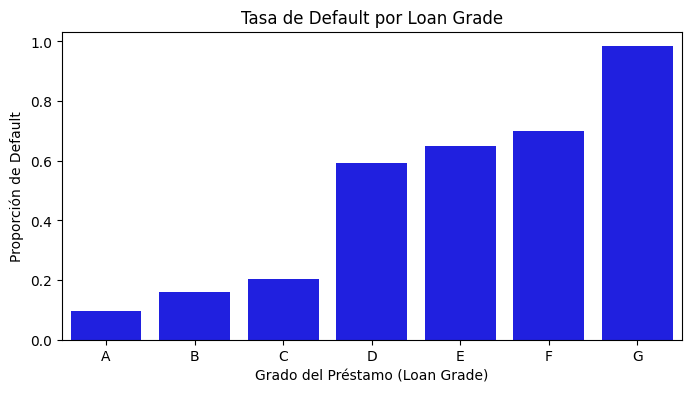

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

# barplot calcula automáticamente la media de loan_status (tasa de default)
sns.barplot(
    data=tabla,
    x='loan_grade',
    y='loan_status',
    order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    color='blue',
    errorbar=None  # Quita las líneas de error para un gráfico más limpio
)

plt.title('Tasa de Default por Loan Grade')
plt.xlabel('Grado del Préstamo (Loan Grade)')
plt.ylabel('Proporción de Default')

plt.show()

In [65]:
# Tasa de default (porcentaje de loan_status = 1) por cada categoría
tasa_default_grade = tabla.groupby('loan_grade')['loan_status'].mean().mul(100).round(2)
print("--- Tasa de Default (%) por Loan Grade ---")
print(tasa_default_grade)

--- Tasa de Default (%) por Loan Grade ---
loan_grade
A     9.53
B    15.94
C    20.20
D    59.16
E    64.91
F    70.13
G    98.33
Name: loan_status, dtype: float64


PERSON_HOME_OWNERSHIP

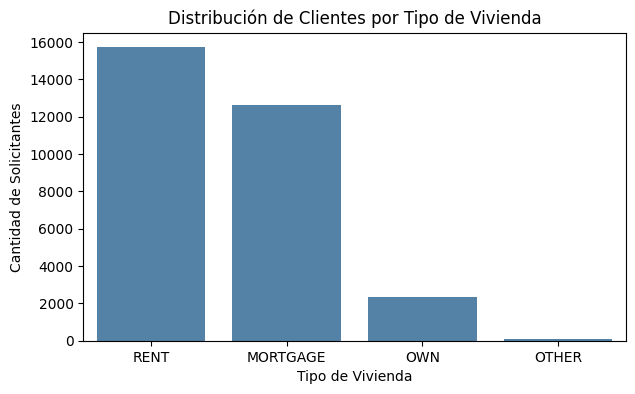

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))

# Gráfico de barras azul sólido
sns.countplot(
    data=tabla,
    x='person_home_ownership',
    color='steelblue',
    order=tabla['person_home_ownership'].value_counts().index  # Ordena de mayor a menor
)

plt.title('Distribución de Clientes por Tipo de Vivienda')
plt.xlabel('Tipo de Vivienda')
plt.ylabel('Cantidad de Solicitantes')

plt.show()

In [67]:
# Tabla de frecuencias absolutas y porcentajes
frecuencia_vivienda = pd.DataFrame({
    'Cantidad': tabla['person_home_ownership'].value_counts(),
    'Porcentaje (%)': tabla['person_home_ownership'].value_counts(normalize=True) * 100
}).round(2)

print("--- Distribución de person_home_ownership ---")
print(frecuencia_vivienda)

--- Distribución de person_home_ownership ---
                       Cantidad  Porcentaje (%)
person_home_ownership                          
RENT                      15716           51.04
MORTGAGE                  12649           41.08
OWN                        2322            7.54
OTHER                       105            0.34


###PERSON_HOME_OWNERSHIP Y LOAN_GRADE

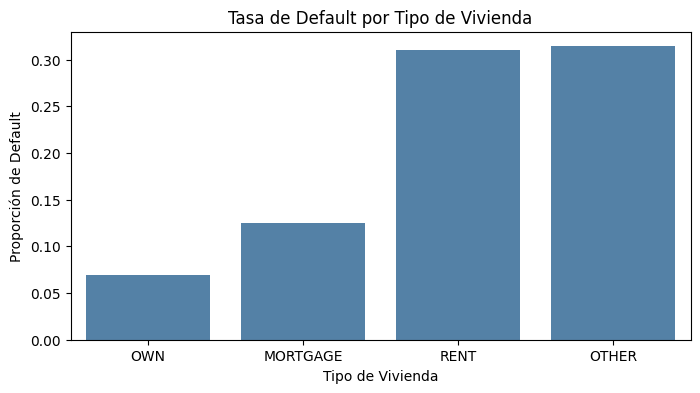

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

# barplot calcula la media (tasa de default) de cada categoría
sns.barplot(
    data=tabla,
    x='person_home_ownership',
    y='loan_status',
    order=['OWN', 'MORTGAGE', 'RENT', 'OTHER'],
    color='steelblue',
    errorbar=None
)

plt.title('Tasa de Default por Tipo de Vivienda')
plt.xlabel('Tipo de Vivienda')
plt.ylabel('Proporción de Default')

plt.show()

Al convertir la cantidad absoluta a un porcentaje (proporción entre 0 y 1), estás comparando peras con peras.

Además con el .mean() también se suele normalizar

In [69]:
# Tasa de default (%) por tipo de vivienda
tasa_vivienda = tabla.groupby('person_home_ownership')['loan_status'].mean().mul(100).round(2)

print("--- Tasa de Default (%) por Tipo de Vivienda ---")
print(tasa_vivienda)

--- Tasa de Default (%) por Tipo de Vivienda ---
person_home_ownership
MORTGAGE    12.53
OTHER       31.43
OWN          6.98
RENT        31.04
Name: loan_status, dtype: float64


LOAN_INTENT

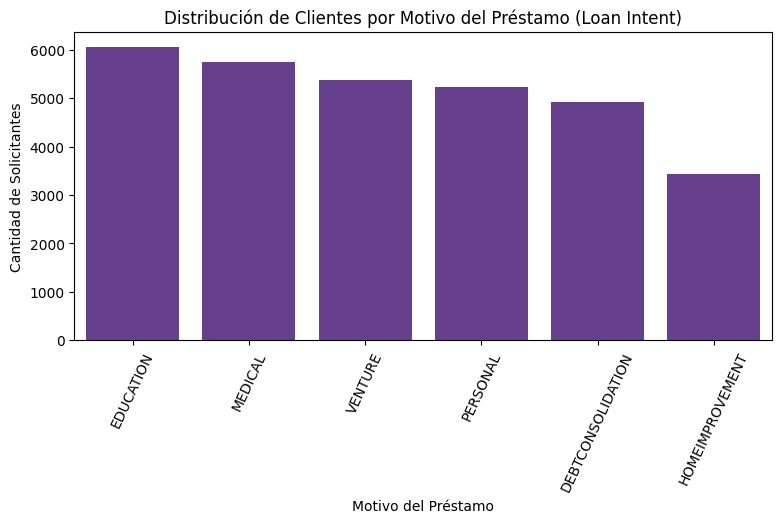

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))

# Gráfico de barras ordenado por frecuencia en color violeta
sns.countplot(
    data=tabla,
    x='loan_intent',
    order=tabla['loan_intent'].value_counts().index,
    color='rebeccapurple'
)

plt.title('Distribución de Clientes por Motivo del Préstamo (Loan Intent)')
plt.xlabel('Motivo del Préstamo')
plt.ylabel('Cantidad de Solicitantes')

# Rotar los nombres del eje X a vertical
plt.xticks(rotation=65)

plt.show()

Hasta aca encontre que se pide pocos prestamos para remodelar casas HOMEIMPROVEMENT, mientras que en todo las demas variables se mantienen casi constantes

In [71]:
# Tabla de frecuencias absolutas y porcentajes
frecuencia_intent = pd.DataFrame({
    'Cantidad': tabla['loan_intent'].value_counts(),
    'Porcentaje (%)': tabla['loan_intent'].value_counts(normalize=True) * 100
}).round(2)

print("--- Distribución de loan_intent ---")
print(frecuencia_intent)

--- Distribución de loan_intent ---
                   Cantidad  Porcentaje (%)
loan_intent                                
EDUCATION              6063           19.69
MEDICAL                5745           18.66
VENTURE                5384           17.49
PERSONAL               5238           17.01
DEBTCONSOLIDATION      4926           16.00
HOMEIMPROVEMENT        3436           11.16


###LOAN_INTENT y LOAN_STATUS

Aca puedo ver en que tipo de prestamos hay mayor riesgo de default hay mas riesgo de default

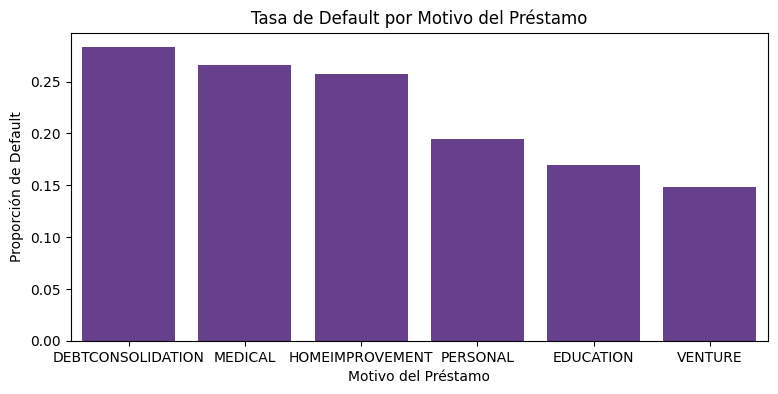

--- Tasa de Default (%) por Motivo ---
loan_intent
DEBTCONSOLIDATION    28.30
EDUCATION            16.99
HOMEIMPROVEMENT      25.73
MEDICAL              26.61
PERSONAL             19.47
VENTURE              14.88
Name: loan_status, dtype: float64


In [72]:
plt.figure(figsize=(9, 4))

# Tasa de default por motivo
sns.barplot(
    data=tabla,
    x='loan_intent',
    y='loan_status',
    order=tabla.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False).index,
    color='rebeccapurple',
    errorbar=None

)

plt.title('Tasa de Default por Motivo del Préstamo')
plt.xlabel('Motivo del Préstamo')
plt.ylabel('Proporción de Default')

plt.show()

# Imprimir valores exactos
tasa_intent = tabla.groupby('loan_intent')['loan_status'].mean().mul(100).round(2)
print("--- Tasa de Default (%) por Motivo ---")
print(tasa_intent)

CB_PERSON_DEFAULT_ON_FILE

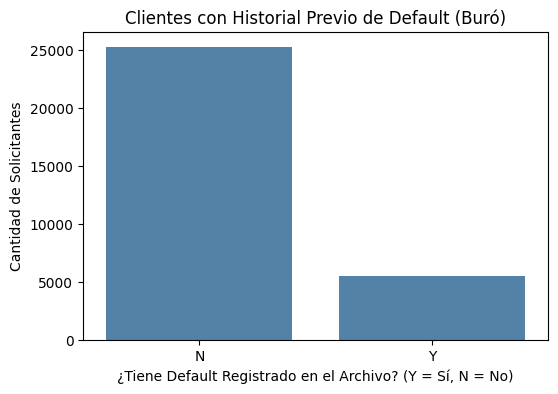

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# Gráfico de barras simple
sns.countplot(
    data=tabla,
    x='cb_person_default_on_file',
    order=['N', 'Y'],
    color='steelblue'
)

plt.title('Clientes con Historial Previo de Default (Buró)')
plt.xlabel('¿Tiene Default Registrado en el Archivo? (Y = Sí, N = No)')
plt.ylabel('Cantidad de Solicitantes')

plt.show()

In [74]:
# Tabla de frecuencias absolutas y porcentajes
frecuencia_default_file = pd.DataFrame({
    'Cantidad': tabla['cb_person_default_on_file'].value_counts(),
    'Porcentaje (%)': tabla['cb_person_default_on_file'].value_counts(normalize=True) * 100
}).round(2)

print("--- Distribución de cb_person_default_on_file ---")
print(frecuencia_default_file)

--- Distribución de cb_person_default_on_file ---
                           Cantidad  Porcentaje (%)
cb_person_default_on_file                          
N                             25294           82.14
Y                              5498           17.86


###CB_PERSON_DEFAULT_ON_FILE Y LOAN_GRADE

El historial de default antecedentes y si defaulteó el prestamo actual

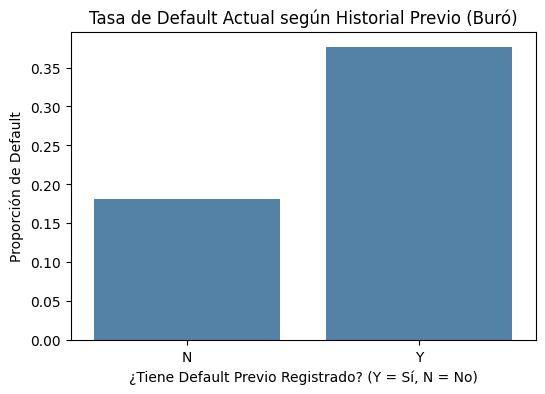

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# barplot muestra la tasa de default para N y Y
sns.barplot(
    data=tabla,
    x='cb_person_default_on_file',
    y='loan_status',
    order=['N', 'Y'],
    color='steelblue',
    errorbar=None
)

plt.title('Tasa de Default Actual según Historial Previo (Buró)')
plt.xlabel('¿Tiene Default Previo Registrado? (Y = Sí, N = No)')
plt.ylabel('Proporción de Default')

plt.show()

LOAN_PERCENT_INCOME

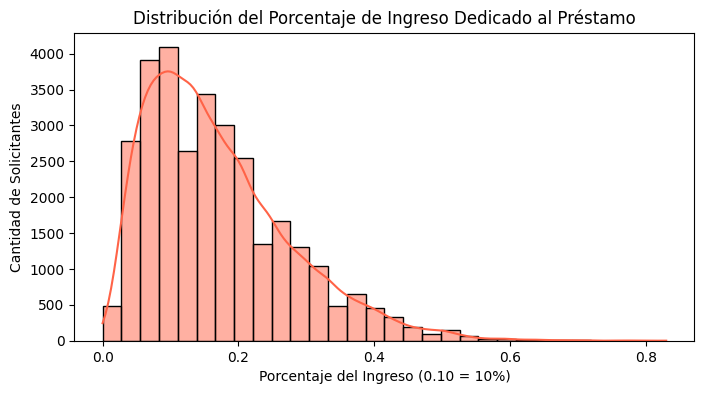

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

# Histograma de loan_percent_income con curva de densidad (KDE)
sns.histplot(
    data=tabla,
    x='loan_percent_income',
    bins=30,
    kde=True,
    color='tomato'
)

plt.title('Distribución del Porcentaje de Ingreso Dedicado al Préstamo')
plt.xlabel('Porcentaje del Ingreso (0.10 = 10%)')
plt.ylabel('Cantidad de Solicitantes')

plt.show()

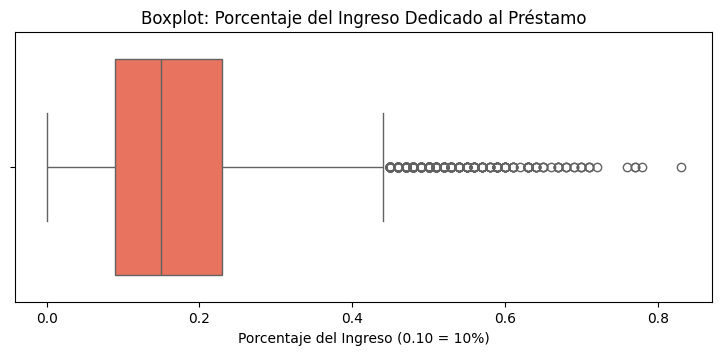

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 3.5))

# Boxplot horizontal en azul estético
sns.boxplot(
    data=tabla,
    x='loan_percent_income',
    color='tomato'
)


plt.title('Boxplot: Porcentaje del Ingreso Dedicado al Préstamo')
plt.xlabel('Porcentaje del Ingreso (0.10 = 10%)')

plt.show()

###LOAN_PERCENT_INCOME Y LOAN_STATUS

El 50% de todos tus solicitantes piden un préstamo que equivale a entre el 10% y el 22% de sus ingresos anuales.
Muestra que el comportamiento habitual o estándar de la cartera es pedir montos moderados que no superan un cuarto de su sueldo anual

El 50% de la izquierda: La mitad de los clientes de tu base piden un préstamo que representa menos del 15% (0.15) de sus ingresos anuales.

El 50% de la derecha: La otra mitad pide un préstamo que representa más del 15% de sus ingresos.

Las dos "T" Sirven para separar lo que se considera un comportamiento habitual o estándar de lo que ya pasa a ser un valor atípico (outlier).


Ubicación: En tu gráfico está parada en torno al 0.44 (44%).

Significado: Marca el porcentaje máximo de ingreso que se considera normal o esperable dentro de la masa general de clientes.

Cualquier cliente que pida un préstamo por encima de ese valor (los puntos que están a su derecha) deja de ser "habitual" y entra en la categoría de outlier / riesgo atípico.

La "T" de la Izquierda (Límite Inferior)
Ubicación: Está parada cerca del 0.00 (0%).

Significado: Marca el límite mínimo esperable para esta variable.

Los pagadores (No Default - 0): Tienen su mediana en ~0.15 (15%) y el 50% central concentrado en un rango bajo y conservador (10% a 20%).

Los morosos (Default - 1): Tienen la mediana mucho más arriba (~0.22 / 22%) y su 50% central se desplaza hacia la zona de alto compromiso financiero (15% a 35%).

Conclusión: A mayor porcentaje del ingreso comprometido en la cuota/préstamo, la probabilidad de caer en mora aumenta drásticamente.

En los clientes que cumplen, el comportamiento atípico (outliers) empieza muy temprano: a partir del 0.38 - 0.39 (39%). Es decir, casi nadie que pague bien compromete más del 39% de su sueldo.

En los clientes que defaultean, el bigote de comportamiento "normal dentro de la morosidad" se extiende hasta un 0.64 - 0.65 (65%).

Conclusión: Los clientes que caen en default no solo piden más en promedio, sino que operan habitualmente en niveles de endeudamiento extremos que para un pagador normal serían casos excepcionales.

/tmp/ipykernel_2699/67390074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


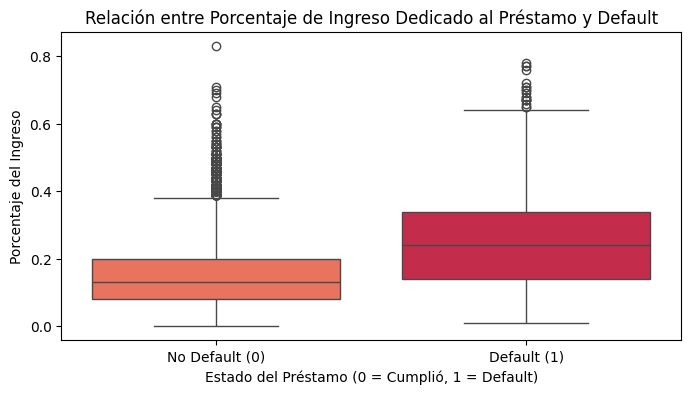

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

# Boxplot agrupado por loan_status
sns.boxplot(
    data=tabla,
    x='loan_status',
    y='loan_percent_income',
    palette=['tomato', 'crimson']
)

plt.title('Relación entre Porcentaje de Ingreso Dedicado al Préstamo y Default')
plt.xlabel('Estado del Préstamo (0 = Cumplió, 1 = Default)')
plt.ylabel('Porcentaje del Ingreso')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])

plt.show()

##ANALISIS DE RELACIONES DE MULTIPLES VARIABLES

###LOAN_PERCENT_INCOME, LOAN_INT y LOAN_STATUS

Existe una interacción directa entre loan_percent_income y loan_int_rate sobre la morosidad. Si bien un porcentaje alto de ingreso comprometido (>30%) es por sí solo un predictor fuerte de default, el riesgo se amplifica exponencialmente cuando se combina con tasas de interés superiores al 15%, generando un 'doble estrangulamiento' financiero sobre el cliente.

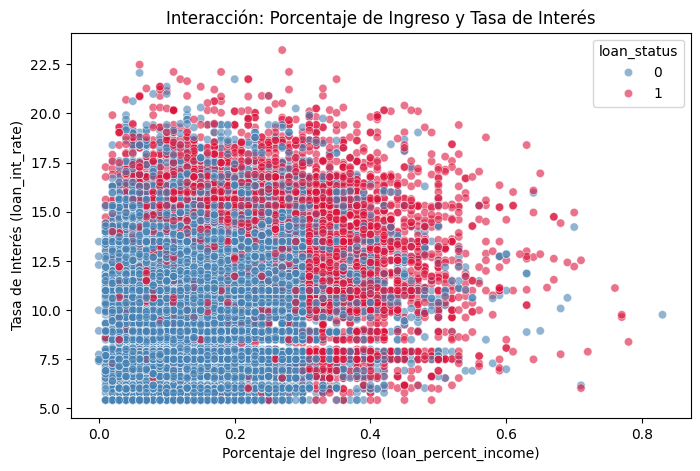

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=tabla,
    x='loan_percent_income',
    y='loan_int_rate',
    hue='loan_status',
    alpha=0.6,
    palette=['steelblue', 'crimson']
)
plt.title('Interacción: Porcentaje de Ingreso y Tasa de Interés')
plt.xlabel('Porcentaje del Ingreso (loan_percent_income)')
plt.ylabel('Tasa de Interés (loan_int_rate)')
plt.show()

###PERSON_HOME_OWNERSHIP, LOAN_PERSON_INCOME Y LOAN_STATUS

¿Por qué? Quienes alquilan (RENT) suelen tener menos margen financiero que los que tienen hipoteca (MORTGAGE) o casa propia (OWN).

La condición habitacional (person_home_ownership) actúa como un factor de riesgo multiplicador junto con loan_percent_income. Un mismo nivel de endeudamiento (por ejemplo, 25% del sueldo) representa un riesgo significativamente mayor de default en un solicitante que alquila (RENT) que en uno con vivienda propia (OWN), debido a los costos fijos obligatorios de alquiler que limitan su capacidad de pago frente a imprevistos

El análisis por tipo de vivienda revela dinámicas de riesgo muy distintas: mientras que en los clientes con hipoteca (MORTGAGE) la zona segura es extremadamente estrecha (solo hasta el 13% del ingreso), en los propietarios (OWN) la mora se activa tempranamente a partir del 20%-22% de compromiso salarial y se extiende hasta niveles severos del 56%

Incluso en el grupo de clientes morosos que tienen casa propia, el sobreendeudamiento no suele pasar del 56%. Quienes superan ese 56% son casos completamente excepcionales.

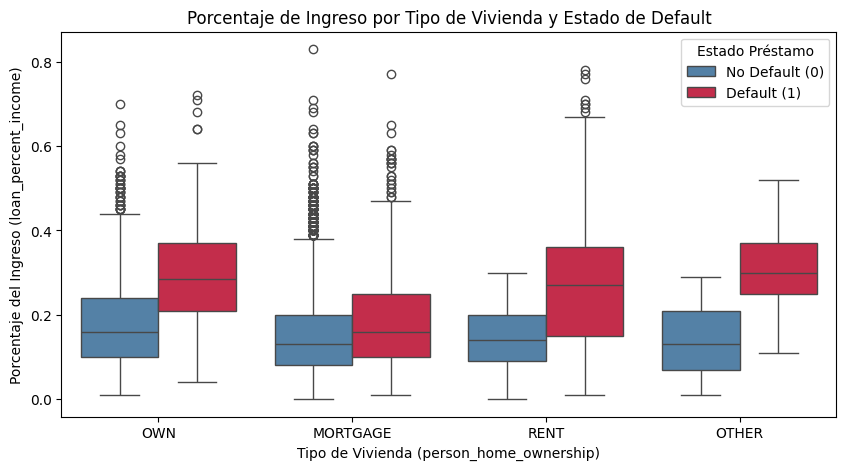

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Creamos una columna temporal para los nombres visuales
tabla['estado_nombre'] = tabla['loan_status'].map({0: 'No Default (0)', 1: 'Default (1)'})

sns.boxplot(
    data=tabla,
    x='person_home_ownership',
    y='loan_percent_income',
    hue='estado_nombre',
    palette={'No Default (0)': 'steelblue', 'Default (1)': 'crimson'}
)

plt.title('Porcentaje de Ingreso por Tipo de Vivienda y Estado de Default')
plt.xlabel('Tipo de Vivienda (person_home_ownership)')
plt.ylabel('Porcentaje del Ingreso (loan_percent_income)')
plt.legend(title='Estado Préstamo')

plt.show()

###LOAN_INT_RATE, lOAN_GRADE Y LOAN_STATUS

Permite validar la efectividad del sistema de scoring interno: los préstamos de grado 'A' deberían tener muy poco default y tasas bajas, mientras que los grados 'D', 'E' o 'F' deberían acumular la mayor mora y tasas más altas

De todas las columnas, agrupá por grado y rango de tasa, pero calculale el promedio únicamente a la columna loan_status.

El mean() se aplica únicamente a loan_status

loan_grade y rango_tasa no llevan mean(); actúan exclusivamente como las categorías de agrupación (los grupos que van en las filas y en el eje del gráfico)

El sistema de calificación del banco funciona correctamente. Los clientes clasificados con mejor nota (A) tienen una tasa de mora baja (habitualmente menor al 10%), mientras que los calificados con notas bajas (D a G) concentran el mayor riesgo, superando en algunos casos el 40%-50% de incumplimiento.

La tasa de interés actúa como un factor de presión adicional. Incluso dentro del mismo grupo de riesgo asignado por el banco, a los clientes a los que se les cobra una tasa más alta les cuesta más pagar la cuota, lo que incrementa su probabilidad final de caer en default.

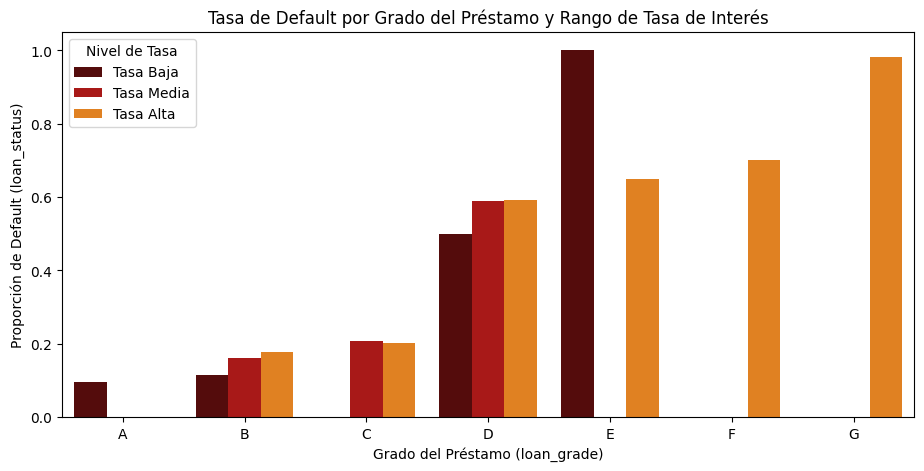

In [90]:
# Rangos para la tasa de interés
tabla['rango_tasa'] = pd.qcut(
    tabla['loan_int_rate'],
    q=3,
    labels=['Tasa Baja', 'Tasa Media', 'Tasa Alta']
)

# Calcule la tasa promedio de default por Grado y Rango de Tasa
mora = tabla.groupby(['loan_grade', 'rango_tasa'], observed=False)['loan_status'].mean().reset_index()

# 3. Gráfico de barras agrupadas
plt.figure(figsize=(11, 5))

sns.barplot(
    data=mora,
    x='loan_grade',
    y='loan_status',
    hue='rango_tasa',
    palette='gist_heat'
)

plt.title('Tasa de Default por Grado del Préstamo y Rango de Tasa de Interés')
plt.xlabel('Grado del Préstamo (loan_grade)')
plt.ylabel('Proporción de Default (loan_status)')
plt.legend(title='Nivel de Tasa')

plt.show()

###CB_PERSON_DEFAULT_ON_FILE, LOAN_GRADE Y LOAN_STATUS

Este gráfico busca responder si el comportamiento pasado (cb_person_default_on_file) añade riesgo adicional incluso a personas que tienen la misma calificación de crédito asignada por el banco.

El historial de incumplimiento previo (cb_person_default_on_file = Y) actúa como un factor multiplicador de riesgo directo. Un cliente clasificado en un grado intermedio pero con antecedente previo presenta un riesgo de mora equivalente o superior al de un cliente en un grado peor pero sin antecedentes

agrupa a las personas por su historial y grado, y luego mira cuántos cayeron en default dentro de cada uno de esos grupos.

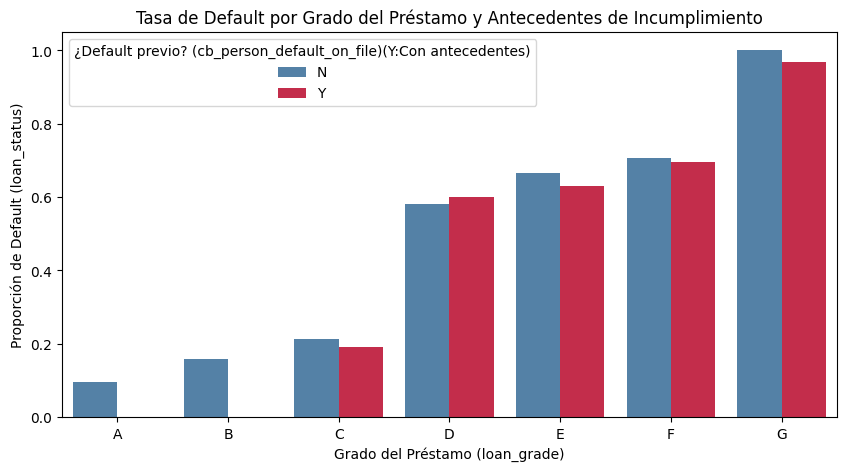

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# 1. Calculamos la tasa promedio de default agrupando por Historial y Grado
mora_historial = tabla.groupby(['loan_grade', 'cb_person_default_on_file'], observed=False)['loan_status'].mean().reset_index()

# 2. Gráfico de barras agrupadas
sns.barplot(
    data=mora_historial,
    x='loan_grade',
    y='loan_status',
    hue='cb_person_default_on_file',
    palette=['steelblue', 'crimson']
)

plt.title('Tasa de Default por Grado del Préstamo y Antecedentes de Incumplimiento')
plt.xlabel('Grado del Préstamo (loan_grade)')
plt.ylabel('Proporción de Default (loan_status)')
plt.legend(title='¿Default previo? (cb_person_default_on_file)(Y:Con antecedentes)')

plt.show()

LOAN_GRADE,LOAN_INTENT ,CB_PERSON_CRED_HIST_LENGHT Y LOAN_STATUS

Aca me surgio la duda si cb_person_cred_hist_length era relevante y nos daba alguna información por ejemplo nos aporta que en la mayoria de las veces la antiguedad crediticia corta tiene que ver con el default

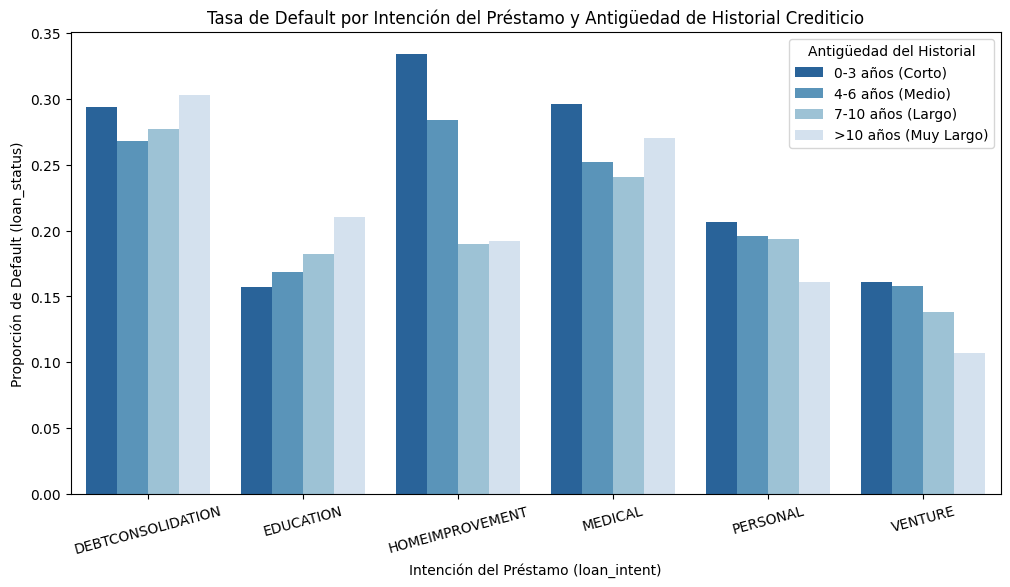

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Crear rangos para la antigüedad del historial (cb_person_cred_hist_length)
tabla['rango_historial'] = pd.cut(
    tabla['cb_person_cred_hist_length'],
    bins=[-1, 3, 6, 10, 100],
    labels=['0-3 años (Corto)', '4-6 años (Medio)', '7-10 años (Largo)', '>10 años (Muy Largo)']
)

# 2. Calcular la tasa promedio de default por Intención de Préstamo y Rango de Historial
mora_hist_intent = tabla.groupby(['loan_intent', 'rango_historial'], observed=False)['loan_status'].mean().reset_index()

# 3. Gráfico de barras agrupadas
plt.figure(figsize=(12, 6))

sns.barplot(
    data=mora_hist_intent,
    x='loan_intent',
    y='loan_status',
    hue='rango_historial',
    palette='Blues_r'
)

plt.title('Tasa de Default por Intención del Préstamo y Antigüedad de Historial Crediticio')
plt.xlabel('Intención del Préstamo (loan_intent)')
plt.ylabel('Proporción de Default (loan_status)')
plt.legend(title='Antigüedad del Historial')
plt.xticks(rotation=15)

plt.show()

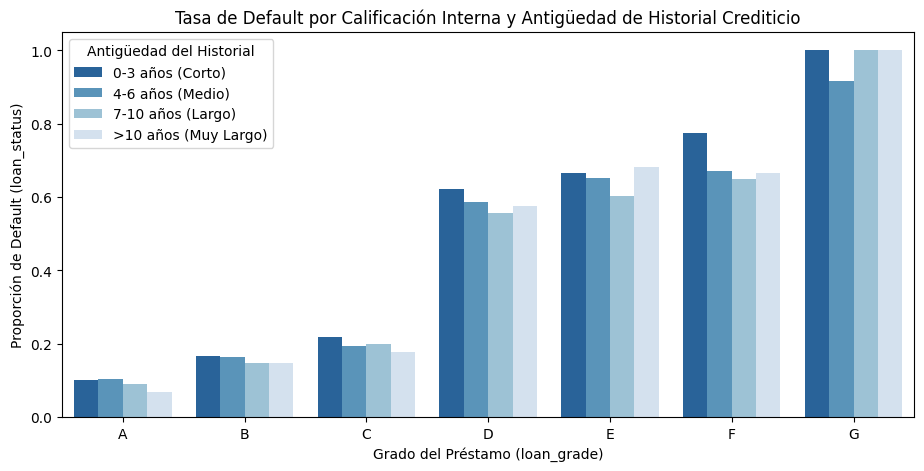

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Crear rangos para la antigüedad del historial
tabla['rango_historial'] = pd.cut(
    tabla['cb_person_cred_hist_length'],
    bins=[-1, 3, 6, 10, 100],
    labels=['0-3 años (Corto)', '4-6 años (Medio)', '7-10 años (Largo)', '>10 años (Muy Largo)']
)

# 2. Agrupar por Calificación Interna (loan_grade) y Rango de Historial
mora_hist_grade = tabla.groupby(['loan_grade', 'rango_historial'], observed=False)['loan_status'].mean().reset_index()

# 3. Gráfico de barras agrupadas
plt.figure(figsize=(11, 5))

sns.barplot(
    data=mora_hist_grade,
    x='loan_grade',
    y='loan_status',
    hue='rango_historial',
    palette='Blues_r'
)

plt.title('Tasa de Default por Calificación Interna y Antigüedad de Historial Crediticio')
plt.xlabel('Grado del Préstamo (loan_grade)')
plt.ylabel('Proporción de Default (loan_status)')
plt.legend(title='Antigüedad del Historial')

plt.show()

#PREGUNTA Y CONCLUSIONES DEL ANÁLISIS DE DATOS: RIESGO DE INCUMPLIMIENTO

¿Qué características de los solicitantes y de sus préstamos están asociadas con un mayor riesgo de incumplimiento (loan_status = 1)?

El riesgo de incumplimiento en la cartera de créditos no responde a un único factor aislado, sino a la convergencia de vulnerabilidades financieras, presiones de costo y la falta de resguardo patrimonial de los solicitantes.

En primer lugar, la capacidad de pago y la estructura de costos de la deuda representan la causa primaria de la morosidad. Cuando la cuota de un préstamo pasa a absorber una porción sustancial del ingreso del cliente (superando el 20%), el margen de maniobra del hogar frente a imprevistos se reduce drásticamente. Esta situación se agrava cuando el crédito lleva asociadas tasas de interés elevadas; en lugar de mitigar el riesgo de la entidad, el alto costo financiero impone una carga adicional sobre la cuota que termina sofocando al prestatario y acelerando su caída en default.

En segundo lugar, el propósito del financiamiento y la estabilidad habitacional actúan como condicionantes críticos del comportamiento de pago. Existe un contraste marcado entre quienes se endeudan para financiar inversiones de retorno futuro (como educación o emprendimientos) y quienes acuden al crédito motivados por situaciones de urgencia o estrés financiero, tales como gastos médicos imprevistos o la necesidad de consolidar deudas preexistentes. Estos últimos suelen recurrir al financiamiento en un estado previo de fragilidad económica. Al combinar esta vulnerabilidad con una situación habitacional de alquiler o hipoteca activa, el solicitante carece de un colchón patrimonial o de la flexibilidad necesaria para reabsorber shocks financieros, lo que eleva significativamente su probabilidad de mora.

Por último, el historial y la madurez crediticia del solicitante reflejan la consistencia de sus hábitos de pago y la certeza de la evaluación del riesgo. La falta de trayectoria en el sistema financiero o la presencia de antecedentes negativos en el buró no solo incrementan la asimetría de información para la entidad, sino que funcionan como un indicador predictivo de reincidencia. Cuando estos antecedentes se cruzan con calificaciones de riesgo internas desfavorables, se confirma que el incumplimiento es el resultado predecible de combinar un historial frágil con un sobreendeudamiento estructural.

#LAS VARIABLES CON MAYOR IMPACTO

Antes de pasar a ciencia de datos voy a escribir un resumen y las variables con mayor impacto esto me puede ayudar con las predicciones

loan_percent_income (Porcentaje del ingreso comprometido):

Impacto: Muy Alto (Causa Primaria). Es el predictor directo con mayor capacidad explicativa. Cuando la cuota supera el 20% (0.20) de los ingresos del cliente, la probabilidad de incumplimiento se dispara exponencialmente, sin importar otras características del solicitante.

loan_intent (Destino o intención del préstamo):

Impacto: Alto. Separa de manera tajante el riesgo según la motivación financiera. Destinos de urgencia o estrés económico como DEBTCONSOLIDATION y MEDICAL registran las tasas de mora más elevadas (27%- 28% ), mientras que inversiones a futuro (VENTURE, EDUCATION) registran los valores más bajos (~15%- 17%).

cb_person_default_on_file (Antecedente previo de incumplimiento):

Impacto: Alto (Factor Multiplicador). Actúa como un multiplicador directo de riesgo. Contar con un antecedente negativo (Y) eleva sustancialmente la tasa de mora real en cualquier segmento o calificación crediticia en comparación con un historial impecable (N).

loan_int_rate (Tasa de interés del préstamo):

Impacto: Alto (Presión de Costo). Tasas elevadas (>13%) imponen una carga financiera adicional sobre la cuota que termina sofocando la capacidad de pago del prestatario y acelerando su caída en default.

loan_grade (Calificación o scoring interno de riesgo):

Impacto: Medio - Alto. Demuestra una alta correlación con el default real (los grados 'A' y 'B' mantienen mora baja, mientras que 'D' a 'G' concentran la mayor mora), actuando como una síntesis de la evaluación previa del banco.

person_home_ownership (Situación habitacional):

Impacto: Medio. Los inquilinos (RENT) y quienes poseen hipoteca activa (MORTGAGE) muestran menor margen de absorción ante imprevistos económicos en comparación con los propietarios directos (OWN).

cb_person_cred_hist_length (Antigüedad del historial crediticio):

Impacto: Medio - Bajo. Un historial muy corto (0 a 3 años) genera asimetría de información y aumenta la tasa de default, aunque su efecto es secundario en comparación con la capacidad de pago (loan_percent_income) y los antecedentes previos (cb_person_default_on_file).